# Homework 4

# Задача №1 - Лего детальки

Имеется 2 выборки из датасета фотографий лего картинок. Структура одной выборки следующая:
```
test
| -- 'target.jpg'
| -- source
|    | -- '*.jpg'
|           ...
|    | -- '*.jpg'
```
В выборке есть опорное изображение - target.jpg и набор из 20 картинок в папке source.

Ваша задача - написать программу, которая прочитает все изображения и определит на каких изображениях из папки source сфотографирована такая же лего деталька, что и деталь в target.jpg

Результатом выполнения программы должен быть файлик с названиями подходящих изображений. Пример в Datasets/gt
Снизу представлены 2 вспомогательные функции: чтение всех изображений из папки и посчет получившихся метрик точности

Результат выполнения данной задачи напрямую зависит от полученных метрик. Полученные метрики будут вычисляться из метрик по двум тестам $Accuracy=min({Accuracy}_{test1}, {Accuracy}_{test2}$)

| Accuracy | Recall | % Выполнения |
|:--------:|:------:|:------------:|
|< 0.6|< 0.4|0%|
|  >= 0.6  | >= 0.4 |     75%      |
|  >= 0.7  | >= 0.5 |     100%     |
|  >= 0.9  | >= 0.8 |     150%     |

<table><tr>
    <td> <img src="Datasets/test1/target.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="Datasets/test2/target.jpg" alt="Drawing" style="width: 400px;"/> </td>

</tr></table>

In [2]:
from pathlib import Path
import os

def read_all_image_paths(folder):
    folder = Path(folder)
    image_paths = [i.__str__() for i in folder.glob('*.jpg')]
    return image_paths

def return_metrics(gt_path, prediction_path):
    with open(gt_path) as f:
        gt = set([i.strip('\n') for i in f.readlines() if len(i)])
    with open(prediction_path) as f:
        pred = set([i.strip('\n') for i in f.readlines() if len(i)])

    len_dataset = 20

    TP, TN, FP, FN = (0, ) * 4
    for i in pred:
        if i in gt:
            TP += 1
            gt.remove(i)
        else:
            FP += 1
    FN = len(gt)
    TN = len_dataset - TP - FP - FN

    accuracy = (TP + TN) / len_dataset
    recall = TP / (TP + FN)

    print(f'Acc: {accuracy:.2f}')
    print(f'Recall: {recall:.2f}')

print('All paths for test1:')
images_folder = Path(os.path.abspath('')) / 'Datasets' / 'test1' / 'source'
print(read_all_image_paths(images_folder))

print('Example of calculating metrics:')
gt_test1 = Path(os.path.abspath('')) / 'Datasets' / 'gt' / 'test1.txt'
pred = Path(os.path.abspath('')) / 'test1.txt'

return_metrics(gt_test1, pred)

All paths for test1:
['/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00000_2.1_01249.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00001_1.2_00742.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00002_1.1_00798.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00002_2.2_00703.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00003_2.1_00721.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00003_2.2_00345.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00003_2.2_01170.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00004_2.2_00990.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00005_1.1_00167.jpg', '/home/matvey/Projects/MIPT/cv/04_global_feat/homework/Datasets/test1/source/00005_2.2_

In [ ]:
import numpy as np
from skimage import segmentation
import cv2 

from pathlib import Path

def find_contour(img: np.ndarray):
    img1 = cv2.GaussianBlur(img,(7,7),0)
    img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(img1, np.array([0, 0, 125]), np.array([180, 120, 255]))
    mask = cv2.bitwise_not(mask)
    mask = segmentation.clear_border(mask)
    img1 = cv2.Laplacian(mask, cv2.THRESH_BINARY, scale=0.2, ksize=7)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    areas = [cv2.contourArea(c) for c in contours]
    cnt = contours[np.argmax(areas)]

    epsilon = 0.05 * cv2.arcLength(cnt,True)
    cnt = cv2.approxPolyDP(cnt, epsilon, True)

    return cnt

def find_matches(target_path: str, imgs_folder: str):
    target_img = cv2.imread(target_path)
    target_img = cv2.cvtColor(target_img, cv2.COLOR_RGB2BGR)
    target_cnt = find_contour(target_img)

    matches = []
    for img_path in Path(imgs_folder).glob('*.jpg'):
        img = cv2.imread(img_path.__str__())
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cnt= find_contour(img)
        dist = cv2.matchShapes(target_cnt, cnt, cv2.CONTOURS_MATCH_I1, 0)
        if dist < .07:
            matches.append(img_path.name)
    
    return matches

for i in range(1, 3, 1):
    target_path = f"Datasets/test{i}/target.jpg"
    imgs_folder = f"Datasets/test{i}/source"
    matches = find_matches(target_path, imgs_folder)

    print(f"Test {i}:")

    res = f"test{i}.txt"
    with open(res, "w") as f:
        for m in matches:
            f.write(f"{m}\n")

    return_metrics(f"Datasets/gt/{res}", res)
    print()

Test 1:
Acc: 1.00
Recall: 1.00

Test 2:
Acc: 1.00
Recall: 1.00



# Задача №2 - Найти шаблон на изображении с помощью HOG и кросс-корреляции

Ваша задача - написать программу, которая сможет найти шаблон одного глаза на нескольких изображениях, в том числе затемненных. Использовать нужно HOG представление изображений, поиск шаблона сделать с помощью кросс-корреляции 

Изображение глаз человека и шаблон, который нужно на нем найти, находятся в папке hog

<table><tr>
    <td> <img src="hog/eye.png" alt="Drawing" style="width: 400px;"/> 
</tr></table>     

<table><tr>
    <td> <img src="hog/eyes.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/eyes_dark.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/woman.jpg" alt="Drawing" style="width: 200px;"/> </td>

</tr></table>

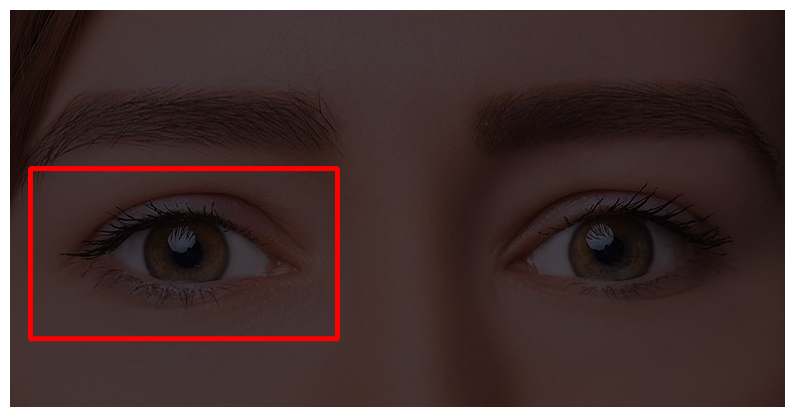

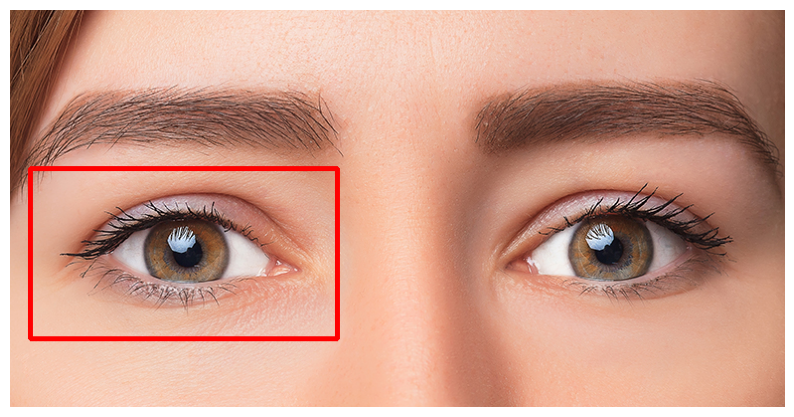

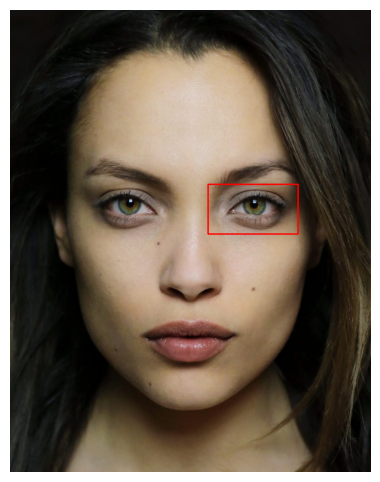

In [38]:
import cv2
import numpy as np
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt

from collections.abc import Iterable

def preprocess_image(img: np.ndarray):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, ksize=(7, 7), sigmaX=1, sigmaY=1)

    return gray

def extract_hog_features(img: np.ndarray, pixels_per_cell: tuple[int, int] = (20, 20)):
    features, hog_image = hog(
        img,
        orientations=4,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2),
        feature_vector=False,
        visualize=True,
        channel_axis=None
    )
    hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 7))

    return features, hog_image.astype('float32')

def find_eye_template(template_path: str, test_images_paths: Iterable[str], threshold):
    template = cv2.imread(template_path)
    template = preprocess_image(template)
    _, template_hog = extract_hog_features(template)
    
    results = []
    
    for img_path in test_images_paths:
        test_img = cv2.imread(img_path)
        test_gray = preprocess_image(test_img)
        _, test_hog = extract_hog_features(test_gray)
        
        res = cv2.matchTemplate(test_hog, template_hog, cv2.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        
        if max_val >= threshold:
            h, w = template.shape
            top_left = max_loc
            bottom_right = (top_left[0] + w, top_left[1] + h)
            cv2.rectangle(test_img, top_left, bottom_right, (0, 0, 255), 3)
            
            results.append(test_img)
    
    return results

template_image = 'hog/eye.png'
test_images = ['hog/eyes_dark.jpg', 'hog/eyes.jpg', 'hog/woman.jpg']

matches = find_eye_template(template_image, test_images, threshold=0.7)

for match in matches:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(match, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()